Data types in df_rp1:
Stage    object
Jan       int64
Feb       int64
Mar       int64
Apr       int64
May       int64
Jun       int64
Jul       int64
Aug       int64
Sep       int64
Oct       int64
Nov       int64
Dec       int64
Jan.1     int64
Feb.1     int64
Mar.1     int64
Apr.1     int64
May.1     int64
Jun.1     int64
Jul.1     int64
Aug.1     int64
Sep.1     int64
dtype: object

Data types in df_abj:
Stage     object
Apr      float64
May      float64
Jun      float64
Jul      float64
Aug      float64
Sep      float64
Oct      float64
Nov      float64
Dec      float64
Jan      float64
Feb      float64
Mar      float64
Apr.1    float64
May.1    float64
Jun.1    float64
Jul.1    float64
Aug.1    float64
Sep.1    float64
dtype: object

Data types in df_jhb:
Stage     object
Apr      float64
May      float64
Jun      float64
Jul      float64
Aug      float64
Sep      float64
Oct      float64
Nov      float64
Dec        int64
Jan        int64
Feb        int64
Mar        int64
Apr.1   

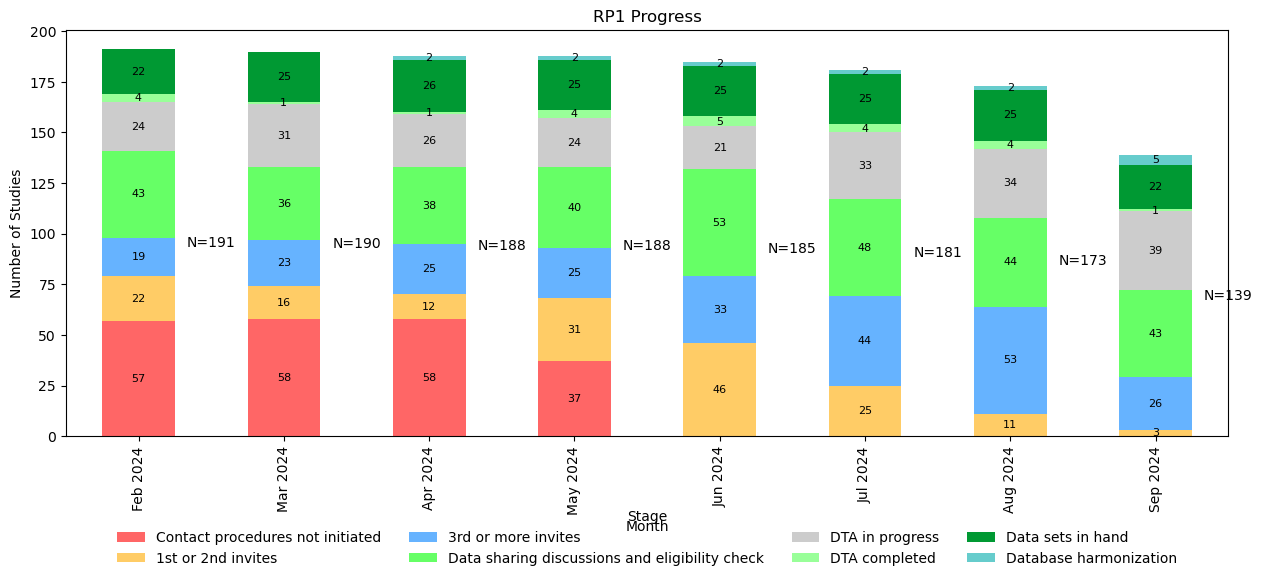

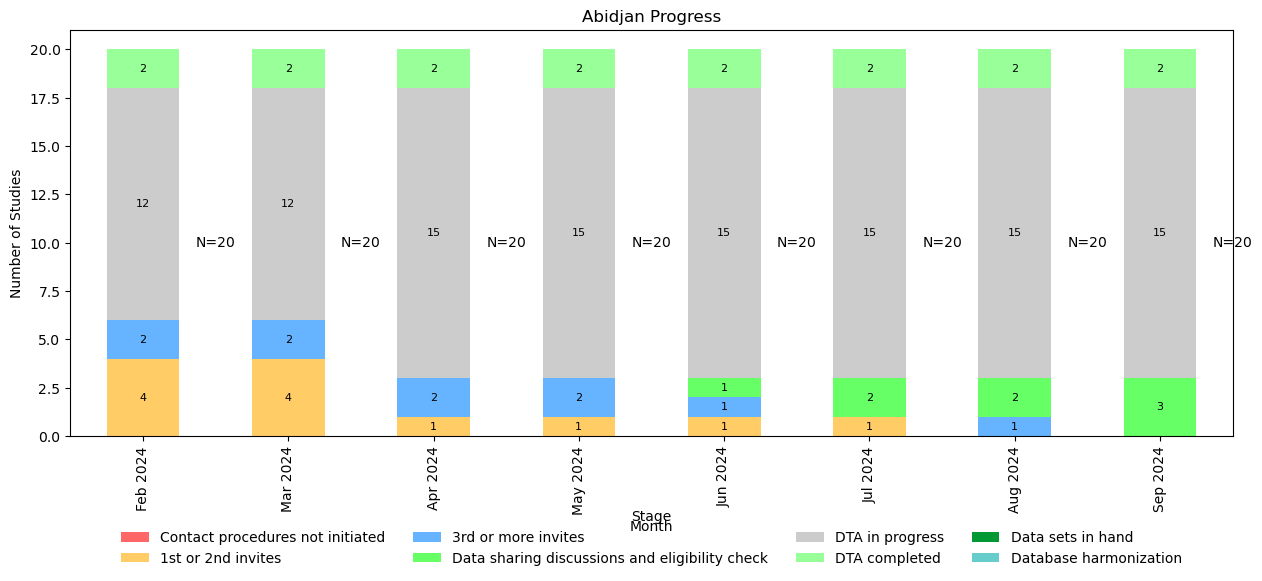

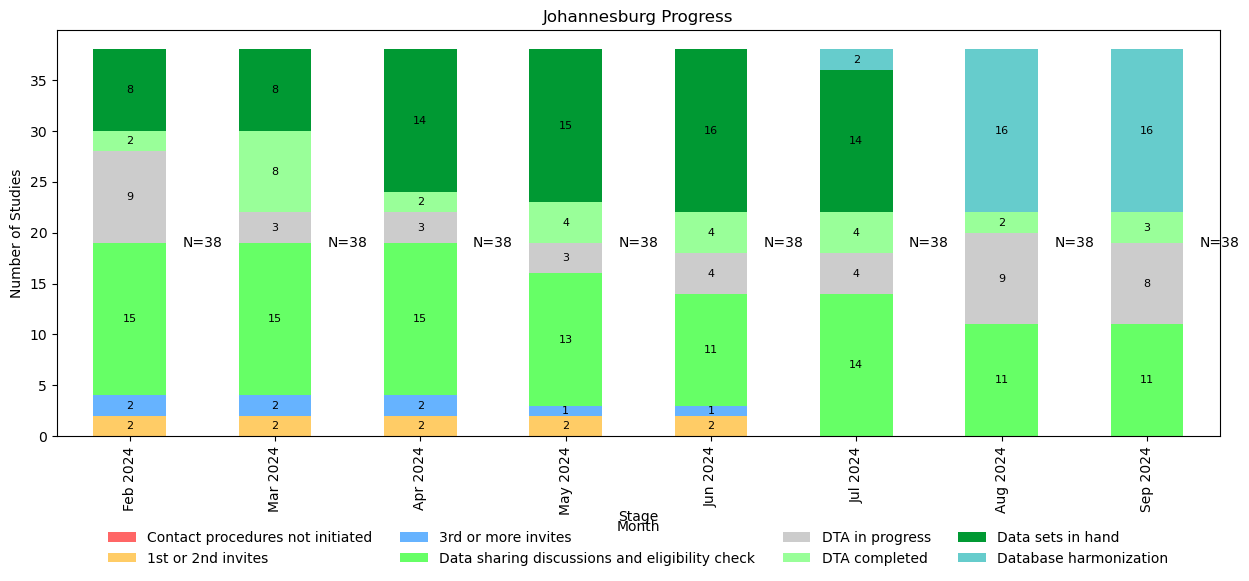

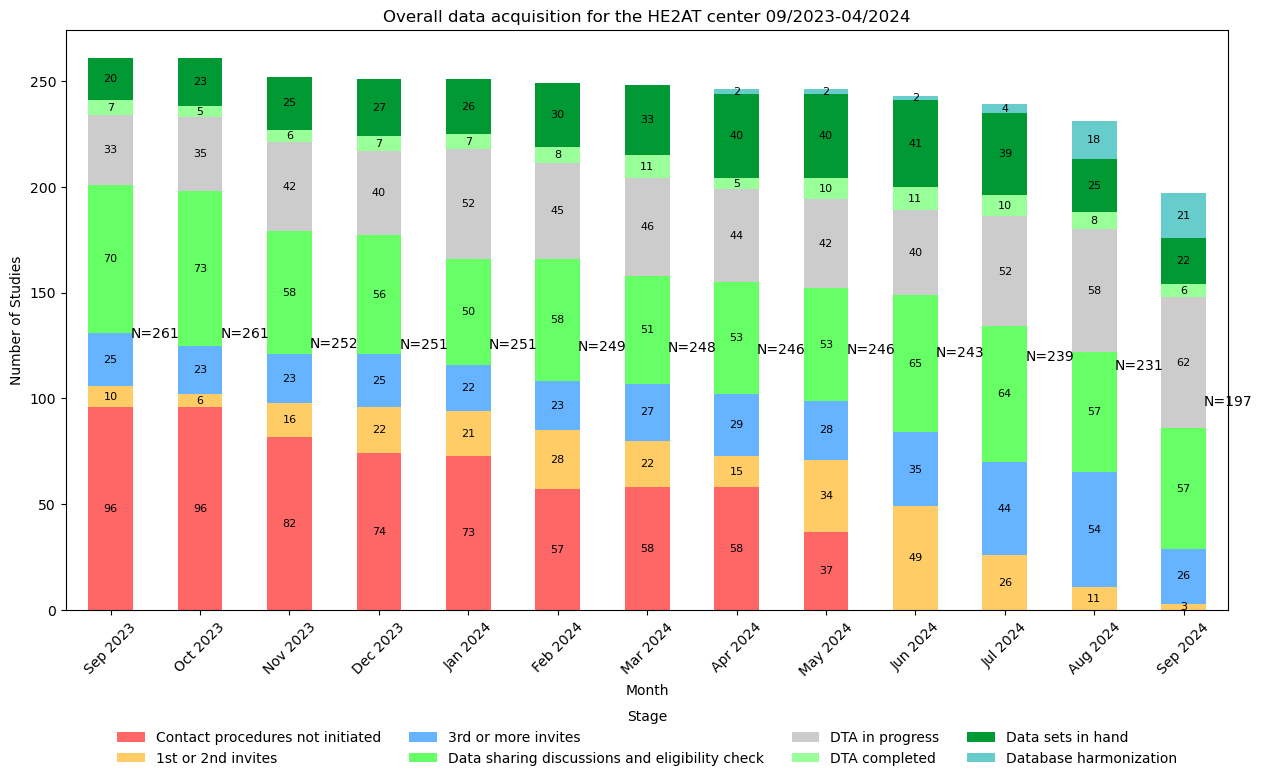

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
xlsx_file = pd.read_excel('HEAT_Tables_0517_am.xlsx', sheet_name=['RP1', 'Abj_outputs', 'Jhb_outputs'])

# Extract each DataFrame from the dictionary
df_rp1 = xlsx_file['RP1']
df_abj = xlsx_file['Abj_outputs']
df_jhb = xlsx_file['Jhb_outputs']

# Print the data types of each DataFrame
print("Data types in df_rp1:")
print(df_rp1.dtypes)
print("\nData types in df_abj:")
print(df_abj.dtypes)
print("\nData types in df_jhb:")
print(df_jhb.dtypes)

# Function to map months and years to columns
def map_month_year(df, start_year=2023):
    month_map = {}
    encountered_dec = False  # Flag to indicate if we've encountered 'Dec'
    months_in_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    for column in df.columns:
        if any(month in column for month in months_in_order):
            base_month_name = ''.join(filter(str.isalpha, column))
            if base_month_name == 'Jan' and encountered_dec:
                start_year += 1
            if base_month_name == 'Dec':
                encountered_dec = True
            month_map[column] = f'{base_month_name} {start_year}'
    return df.rename(columns=month_map)

# Convert the month columns in each DataFrame to a datetime format
df_rp1 = map_month_year(df_rp1)
df_abj = map_month_year(df_abj)
df_jhb = map_month_year(df_jhb)

# Print the new column names to verify the changes
print(df_rp1.columns)
print(df_abj.columns)
print(df_jhb.columns)

# Convert column names to datetime
def convert_column_to_datetime(df):
    new_columns = []
    for col in df.columns:
        if col == 'Stage':
            new_columns.append(col)
        else:
            date_str = col.strip() + ' 1'
            new_columns.append(pd.to_datetime(date_str, format='%b %Y %d', errors='coerce'))
    df.columns = new_columns

# Apply the conversion to each dataframe
for dataframe in [df_rp1, df_abj, df_jhb]:
    convert_column_to_datetime(dataframe)

# Check for unique and common stages
stages_rp1 = set(df_rp1['Stage'].tolist())
stages_abj = set(df_abj['Stage'].tolist())
stages_jhb = set(df_jhb['Stage'].tolist())

unique_to_rp1 = stages_rp1.difference(stages_abj).difference(stages_jhb)
unique_to_abj = stages_abj.difference(stages_rp1).difference(stages_jhb)
unique_to_jhb = stages_jhb.difference(stages_rp1).difference(stages_abj)
common_stages = stages_rp1.intersection(stages_abj).intersection(stages_jhb)

print("Stages unique to df_rp1:", unique_to_rp1)
print("Stages unique to df_abj:", unique_to_abj)
print("Stages unique to df_jhb:", unique_to_jhb)
print("Common stages:", common_stages)

if unique_to_rp1 or unique_to_abj or unique_to_jhb:
    print("There are differences in the stage names across the dataframes.")
else:
    print("All stage names are consistent across the dataframes.")

# Define the color map and stage order
color_map = {
    'Contact procedures not initiated': '#ff6666',  # Red
    '1st or 2nd invites': '#ffcc66',  # Orange
    '3rd or more invites': '#66b3ff',  # Light Blue
    'Data sharing discussions and eligibility check': '#66ff66',  # Light Green
    'DTA in progress': '#cccccc',  # Grey
    'DTA completed': '#99ff99',  # Light Green
    'Data sets in hand': '#009933',  # Dark Green
    'Database harmonization': '#66cccc',  # Teal
    'Ineligible/declined participation/data currently unavailable': '#ff9999'  # Pink
}

stage_order = [
    'Contact procedures not initiated',
    '1st or 2nd invites',
    '3rd or more invites',
    'Data sharing discussions and eligibility check',
    'DTA in progress',
    'DTA completed',
    'Data sets in hand',
    'Database harmonization',
    'Ineligible/declined participation/data currently unavailable'
]


# Function to plot the main stacked bar chart
def plot_stacked_bar_chart(df, title, last_n_months=8, color_map=None, stage_order=None):
    df = df.set_index('Stage').reindex(stage_order).fillna(0).reset_index()
    excluded_df = df[df['Stage'] == 'Ineligible/declined participation/data currently unavailable']
    df = df[df['Stage'] != 'Ineligible/declined participation/data currently unavailable']
    stages_df = df[~df['Stage'].str.contains("Total")]
    transposed_df = stages_df.set_index('Stage').transpose()
    transposed_df = transposed_df.iloc[-last_n_months:]

    fig, ax = plt.subplots(figsize=(15, 7))
    bars = transposed_df.plot(kind='bar', stacked=True, ax=ax, color=[color_map.get(x, '#333333') for x in stage_order])

    for i, month in enumerate(transposed_df.index):
        month_data = transposed_df.loc[month]
        cumulative_height = month_data.sum()
        total_height = month_data.sum()
        x_position = i + 0.5
        ax.text(x_position, cumulative_height / 2, f"N={int(cumulative_height)}", ha='center', va='center')

        for j, (stage, value) in enumerate(month_data.items()):
            if value > 0:
                height = sum(month_data[:j+1]) - (value / 2)
                ax.text(i, height, f'{int(value)}', ha='center', va='center', fontsize=8)

    ax.set_xticklabels([x.strftime('%b %Y') for x in transposed_df.index])
    ax.legend(title='Stage', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=len(stage_order)//2, frameon=False)
    plt.subplots_adjust(bottom=0.3)
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Studies')
    
    return ax

# Function to overlay excluded studies
def overlay_excluded_studies(ax, excluded_df, transposed_df):
    if not excluded_df.empty:
        excluded_df = excluded_df.drop(columns=['Stage'], errors='ignore')
        excluded_totals = excluded_df.transpose().sum()
        if not excluded_totals.empty:
            for i, month in enumerate(transposed_df.index):
                if month in excluded_totals.index:
                    excluded = excluded_totals[month]
                    if excluded > 0:
                        ax.text(i, transposed_df.loc[month].sum() / 2, f"n={int(excluded)}", ha='center', va='bottom', color='red', fontsize=10, fontweight='bold')

# Plot for each DataFrame
ax_rp1 = plot_stacked_bar_chart(df_rp1, 'RP1 Progress', last_n_months=8, color_map=color_map, stage_order=stage_order)
overlay_excluded_studies(ax_rp1, df_rp1[df_rp1['Stage'] == 'Ineligible/declined participation/data currently unavailable'], df_rp1.set_index('Stage').transpose().iloc[-8:])

ax_abj = plot_stacked_bar_chart(df_abj, 'Abidjan Progress', last_n_months=8, color_map=color_map, stage_order=stage_order)
overlay_excluded_studies(ax_abj, df_abj[df_abj['Stage'] == 'Ineligible/declined participation/data currently unavailable'], df_abj.set_index('Stage').transpose().iloc[-8:])

ax_jhb = plot_stacked_bar_chart(df_jhb, 'Johannesburg Progress', last_n_months=8, color_map=color_map, stage_order=stage_order)
overlay_excluded_studies(ax_jhb, df_jhb[df_jhb['Stage'] == 'Ineligible/declined participation/data currently unavailable'], df_jhb.set_index('Stage').transpose().iloc[-8:])

# Combining and plotting function for multiple dataframes
def combine_and_plot_stacked_bars(dfs, title, start_month=9, start_year=2023, stage_order=None, color_map=None):
    combined_df = pd.DataFrame()
    excluded_df = pd.DataFrame()
    for df in dfs:
        df = df.fillna(0).set_index('Stage').reindex(stage_order).fillna(0)
        if 'Ineligible/declined participation/data currently unavailable' in df.index:
            excluded_df = excluded_df.add(df.loc[['Ineligible/declined participation/data currently unavailable']], fill_value=0)
            df = df.drop(['Ineligible/declined participation/data currently unavailable'])
        combined_df = combined_df.add(df, fill_value=0) if not combined_df.empty else df
    transposed_combined_df = combined_df.transpose()
    transposed_combined_df.index = pd.to_datetime(transposed_combined_df.index)
    start_date = pd.Timestamp(year=start_year, month=start_month, day=1)
    filtered_df = transposed_combined_df[transposed_combined_df.index >= start_date]

    fig, ax = plt.subplots(figsize=(15, 10))
    bars = filtered_df.plot(kind='bar', stacked=True, ax=ax, color=[color_map.get(stage) for stage in stage_order])

    for i, month in enumerate(filtered_df.index):
        month_data = filtered_df.loc[month]
        cumulative_height = month_data.sum()
        total_height = month_data.sum()
        x_position = i + 0.5
        ax.text(x_position, cumulative_height / 2, f"N={int(cumulative_height)}", ha='center', va='center')

        for j, (stage, value) in enumerate(month_data.items()):
            if value > 0:
                height = sum(month_data[:j+1]) - (value / 2)
                ax.text(i, height, f'{int(value)}', ha='center', va='center', fontsize=8)

    ax.set_xticklabels([index.strftime('%b %Y') for index in filtered_df.index], rotation=45)
    ax.legend(title='Stage', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=len(stage_order)//2, frameon=False)
    plt.subplots_adjust(bottom=0.3)
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Studies')
    
    overlay_excluded_studies(ax, excluded_df, filtered_df)
    plt.show()

combine_and_plot_stacked_bars(
    [df_rp1, df_abj, df_jhb],
    'Overall data acquisition for the HE2AT center 09/2023-04/2024',
    start_month=9,
    start_year=2023,
    stage_order=stage_order,
    color_map=color_map
)


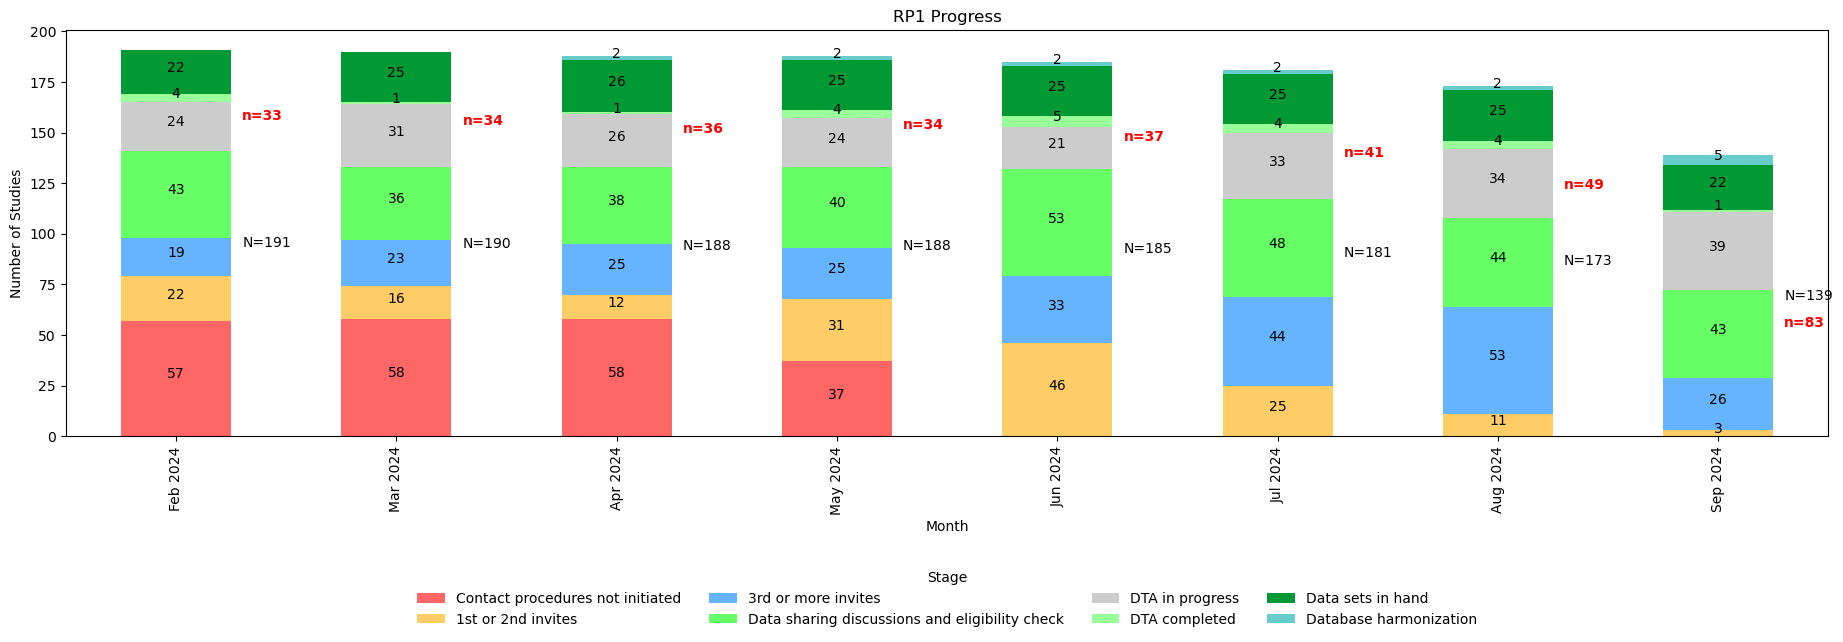

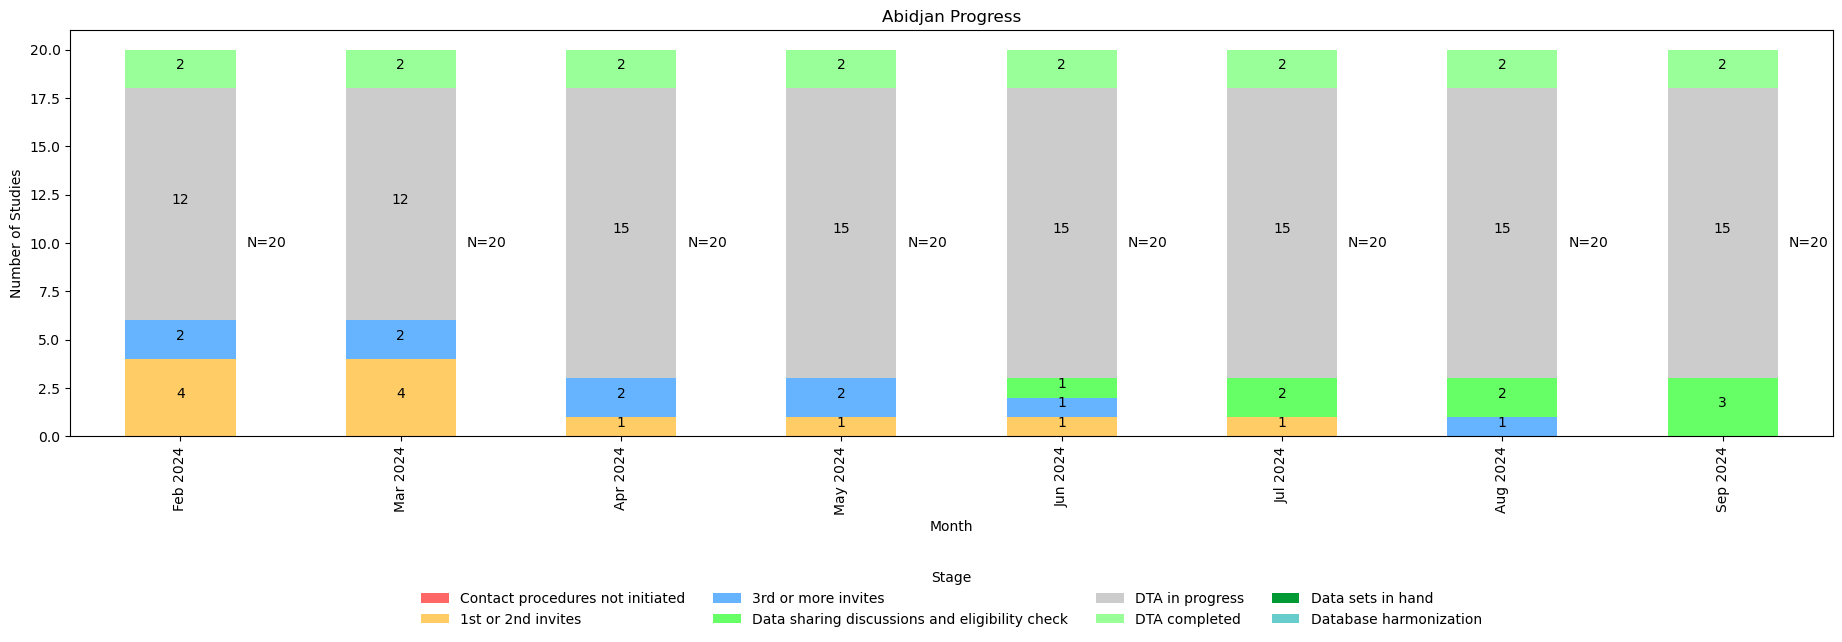

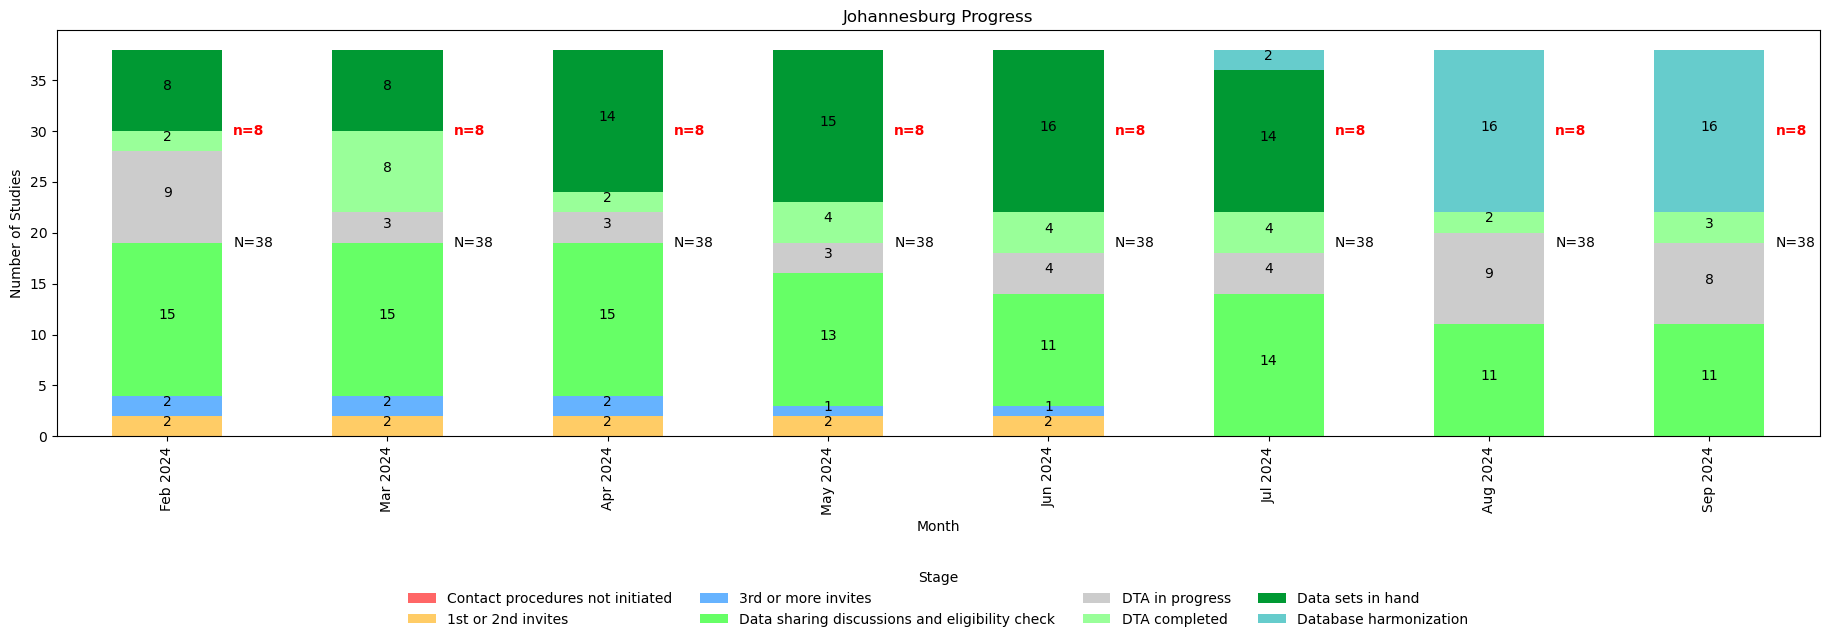

In [3]:
def plot_stacked_bar_chart(df, title, last_n_months=8, color_map=None, stage_order=None):
    df = df.set_index('Stage').reindex(stage_order).reset_index()
    stages_df = df[~df['Stage'].str.contains("Total")]
    transposed_df = stages_df.set_index('Stage').transpose()
    transposed_df = transposed_df.iloc[-last_n_months:]

    # Exclude 'Ineligible/declined participation/data currently unavailable' from the plot
    plot_df = transposed_df.drop(columns=['Ineligible/declined participation/data currently unavailable'], errors='ignore')

    fig, ax = plt.subplots(figsize=(15, 7))
    bars = plot_df.plot(kind='bar', stacked=True, ax=ax, color=[color_map.get(x, '#333333') for x in stage_order if x in plot_df.columns])

    for bar in bars.containers:
        labels = [f'{v.get_height():.0f}' if v.get_height() != 0 else '' for v in bar]
        ax.bar_label(bar, labels=labels, label_type='center', padding=3)

    for i, month in enumerate(transposed_df.index):
        month_data = transposed_df.loc[month]
        cumulative_height = float(month_data.drop('Ineligible/declined participation/data currently unavailable', errors='ignore').sum())
        excluded_height = float(month_data.get('Ineligible/declined participation/data currently unavailable', 0))

        x_position = i + 0.5
        # Adjust the positions of the N= and n= labels
        ax.text(i + 0.3, cumulative_height / 2, f"N={cumulative_height:.0f}", ha='left', va='center')
        if excluded_height > 0:
            ax.text(i + 0.3, cumulative_height - (excluded_height), f"n={excluded_height:.0f}", ha='left', va='center', color='red', fontsize=10, fontweight='bold')

    ax.set_xticklabels([x.strftime('%b %Y') for x in transposed_df.index])
    ax.legend(title='Stage', loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=len(stage_order)//2, frameon=False)
    plt.subplots_adjust(bottom=0.3, right=1.3)
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Studies')
    plt.show()

# Plot for each DataFrame
plot_stacked_bar_chart(df_rp1, 'RP1 Progress', last_n_months=8, color_map=color_map, stage_order=stage_order)
plot_stacked_bar_chart(df_abj, 'Abidjan Progress', last_n_months=8, color_map=color_map, stage_order=stage_order)
plot_stacked_bar_chart(df_jhb, 'Johannesburg Progress', last_n_months=8, color_map=color_map, stage_order=stage_order)

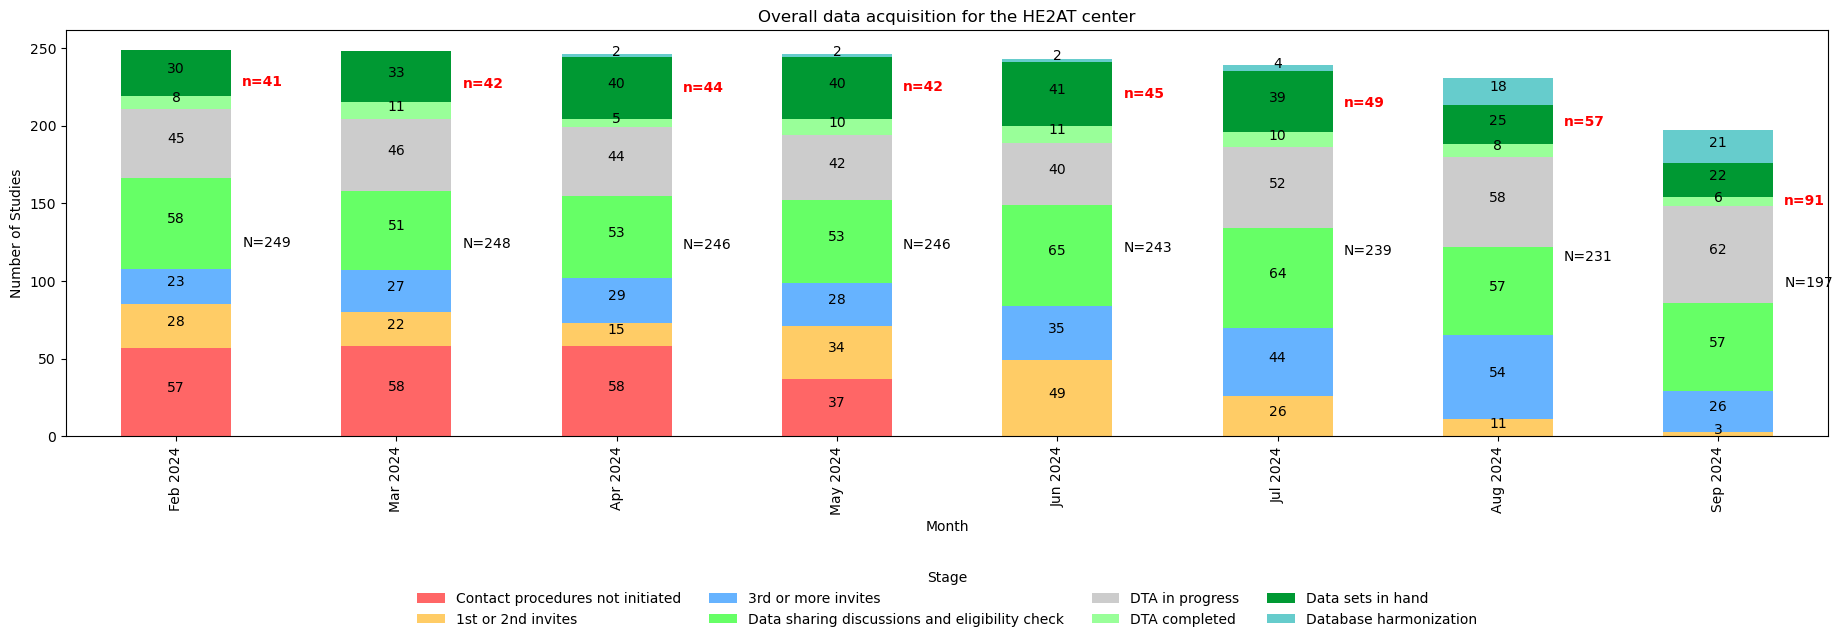

In [4]:
# Function to combine and plot the cumulative stacked bar chart
def plot_cumulative_stacked_bar_chart(dfs, title, last_n_months=8, color_map=None, stage_order=None):
    combined_df = pd.DataFrame()
    for df in dfs:
        df = df.set_index('Stage').reindex(stage_order).reset_index()
        stages_df = df[~df['Stage'].str.contains("Total")]
        if combined_df.empty:
            combined_df = stages_df
        else:
            combined_df = combined_df.set_index('Stage').add(stages_df.set_index('Stage'), fill_value=0).reset_index()
    transposed_df = combined_df.set_index('Stage').transpose()
    transposed_df = transposed_df.iloc[-last_n_months:]

    # Exclude 'Ineligible/declined participation/data currently unavailable' from the plot
    plot_df = transposed_df.drop(columns=['Ineligible/declined participation/data currently unavailable'], errors='ignore')

    fig, ax = plt.subplots(figsize=(15, 7))
    bars = plot_df.plot(kind='bar', stacked=True, ax=ax, color=[color_map.get(x, '#333333') for x in stage_order if x in plot_df.columns])

    for bar in bars.containers:
        labels = [f'{v.get_height():.0f}' if v.get_height() != 0 else '' for v in bar]
        ax.bar_label(bar, labels=labels, label_type='center', padding=3)

    for i, month in enumerate(transposed_df.index):
        month_data = transposed_df.loc[month]
        cumulative_height = float(month_data.drop('Ineligible/declined participation/data currently unavailable', errors='ignore').sum())
        excluded_height = float(month_data.get('Ineligible/declined participation/data currently unavailable', 0))

        x_position = i + 0.5
        # Adjust the positions of the N= and n= labels
        ax.text(i + 0.3, cumulative_height / 2, f"N={cumulative_height:.0f}", ha='left', va='center')
        if excluded_height > 0:
            ax.text(i + 0.3, cumulative_height - (excluded_height / 2), f"n={excluded_height:.0f}", ha='left', va='center', color='red', fontsize=10, fontweight='bold')

    ax.set_xticklabels([x.strftime('%b %Y') for x in transposed_df.index])
    ax.legend(title='Stage', loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=len(stage_order)//2, frameon=False)
    plt.subplots_adjust(bottom=0.3, right=1.3)
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Studies')
    plt.show()

# Plot the cumulative graph
plot_cumulative_stacked_bar_chart(
    [df_rp1, df_abj, df_jhb],
    'Overall data acquisition for the HE2AT center',
    last_n_months=8,
    color_map=color_map,
    stage_order=stage_order
)

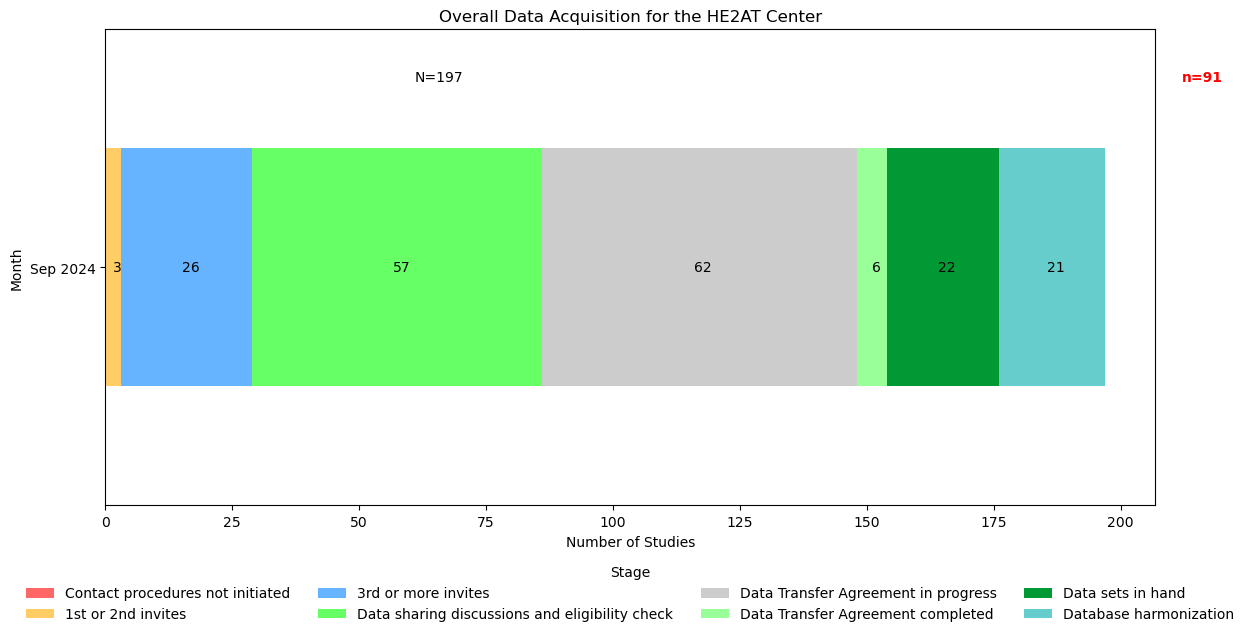

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to combine and plot the cumulative stacked bar chart
def plot_cumulative_stacked_bar_chart(dfs, title, last_n_months=1, color_map=None, stage_order=None):
    combined_df = pd.DataFrame()
    for df in dfs:
        df = df.set_index('Stage').reindex(stage_order).reset_index()
        stages_df = df[~df['Stage'].str.contains("Total")]
        if combined_df.empty:
            combined_df = stages_df
        else:
            combined_df = combined_df.set_index('Stage').add(stages_df.set_index('Stage'), fill_value=0).reset_index()
    transposed_df = combined_df.set_index('Stage').transpose()
    transposed_df = transposed_df.iloc[-last_n_months:]

    # Exclude 'Ineligible/declined participation/data currently unavailable' from the plot
    plot_df = transposed_df.drop(columns=['Ineligible/declined participation/data currently unavailable'], errors='ignore')

    fig, ax = plt.subplots(figsize=(15, 7))  # Adjusted figure size for a longer bar
    bars = plot_df.plot(kind='barh', stacked=True, ax=ax, color=[color_map.get(x, '#333333') for x in stage_order if x in plot_df.columns])

    for bar in bars.containers:
        labels = [f'{v.get_width():.0f}' if v.get_width() != 0 else '' for v in bar]
        ax.bar_label(bar, labels=labels, label_type='center', padding=3)

    for i, month in enumerate(transposed_df.index):
        month_data = transposed_df.loc[month]
        cumulative_width = float(month_data.drop('Ineligible/declined participation/data currently unavailable', errors='ignore').sum())
        excluded_width = float(month_data.get('Ineligible/declined participation/data currently unavailable', 0))

        y_position = i + 0.4
        # Adjust the positions of the N= and n= labels
        ax.text(cumulative_width / 3, y_position, f"N={cumulative_width:.0f}", ha='center', va='center')
        if excluded_width > 0:
            ax.text(cumulative_width + 15, y_position, f"n={excluded_width:.0f}", ha='left', va='center', color='red', fontsize=10, fontweight='bold')

    ax.set_yticklabels([x.strftime('%b %Y') for x in transposed_df.index])
    legend_labels = ['Contact procedures not initiated', '1st or 2nd invites', '3rd or more invites', 'Data sharing discussions and eligibility check', 'Data Transfer Agreement in progress', 'Data Transfer Agreement completed', 'Data sets in hand', 'Database harmonization']
    ax.legend(title='Stage', labels=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(stage_order)//2, frameon=False)
    plt.subplots_adjust(left=0.15, bottom=0.2, right=0.85)
    ax.set_title(title)
    ax.set_ylabel('Month')
    ax.set_xlabel('Number of Studies')
    plt.show()

# Assuming df_rp1, df_abj, df_jhb, color_map, stage_order are already defined
plot_cumulative_stacked_bar_chart(
    [df_rp1, df_abj, df_jhb],
    'Overall Data Acquisition for the HE2AT Center',
    last_n_months=1,
    color_map=color_map,
    stage_order=stage_order
)


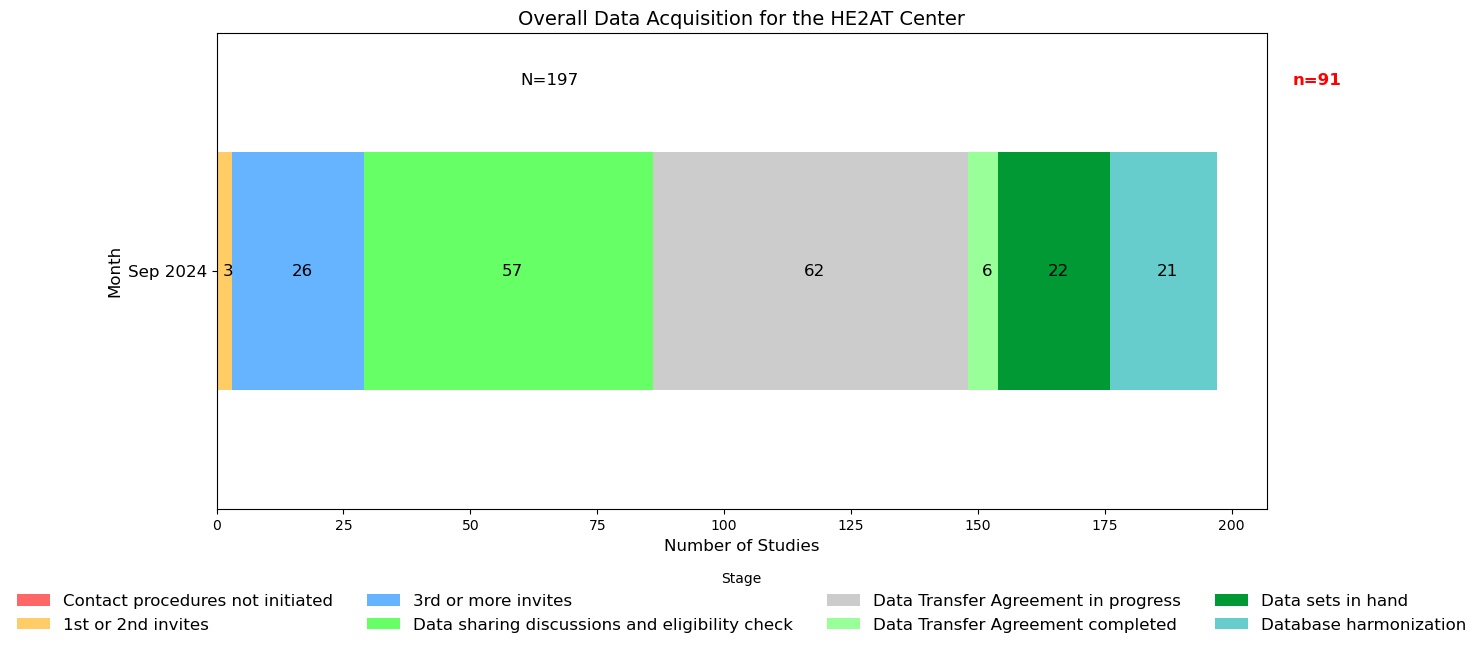

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to combine and plot the cumulative stacked bar chart
def plot_cumulative_stacked_bar_chart(dfs, title, last_n_months=1, color_map=None, stage_order=None):
    combined_df = pd.DataFrame()
    for df in dfs:
        df = df.set_index('Stage').reindex(stage_order).reset_index()
        stages_df = df[~df['Stage'].str.contains("Total")]
        if combined_df.empty:
            combined_df = stages_df
        else:
            combined_df = combined_df.set_index('Stage').add(stages_df.set_index('Stage'), fill_value=0).reset_index()
    transposed_df = combined_df.set_index('Stage').transpose()
    transposed_df = transposed_df.iloc[-last_n_months:]

    # Exclude 'Ineligible/declined participation/data currently unavailable' from the plot
    plot_df = transposed_df.drop(columns=['Ineligible/declined participation/data currently unavailable'], errors='ignore')

    fig, ax = plt.subplots(figsize=(15, 7))  # Adjusted figure size for a longer bar
    bars = plot_df.plot(kind='barh', stacked=True, ax=ax, color=[color_map.get(x, '#333333') for x in stage_order if x in plot_df.columns])

    for bar in bars.containers:
        labels = [f'{v.get_width():.0f}' if v.get_width() != 0 else '' for v in bar]
        ax.bar_label(bar, labels=labels, label_type='center', padding=3, fontsize=12)  # Increased font size

    for i, month in enumerate(transposed_df.index):
        month_data = transposed_df.loc[month]
        cumulative_width = float(month_data.drop('Ineligible/declined participation/data currently unavailable', errors='ignore').sum())
        excluded_width = float(month_data.get('Ineligible/declined participation/data currently unavailable', 0))

        y_position = i + 0.4
        # Adjust the positions of the N= and n= labels
        ax.text(cumulative_width / 3, y_position, f"N={cumulative_width:.0f}", ha='center', va='center', fontsize=12)  # Increased font size
        if excluded_width > 0:
            ax.text(cumulative_width + 15, y_position, f"n={excluded_width:.0f}", ha='left', va='center', color='red', fontsize=12, fontweight='bold')  # Increased font size

    ax.set_yticklabels([x.strftime('%b %Y') for x in transposed_df.index], fontsize=12)  # Increased font size
    ax.set_xlabel('Number of Studies', fontsize=12)  # Increased font size
    ax.set_ylabel('Month', fontsize=12)  # Increased font size
    ax.set_title(title, fontsize=14)  # Increased font size
    legend_labels = ['Contact procedures not initiated', '1st or 2nd invites', '3rd or more invites', 'Data sharing discussions and eligibility check', 'Data Transfer Agreement in progress', 'Data Transfer Agreement completed', 'Data sets in hand', 'Database harmonization']
    ax.legend(title='Stage', labels=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(stage_order)//2, frameon=False, fontsize=12)  # Increased font size
    plt.subplots_adjust(left=0.15, bottom=0.2, right=0.85)
    plt.show()

# Assuming df_rp1, df_abj, df_jhb, color_map, stage_order are already defined
plot_cumulative_stacked_bar_chart(
    [df_rp1, df_abj, df_jhb],
    'Overall Data Acquisition for the HE2AT Center',
    last_n_months=1,
    color_map=color_map,
    stage_order=stage_order
)


In [7]:
import pandas as pd



# Create a DataFrame from the data
df_rp1_countries = pd.read_excel('HEAT_Tables_0517_am.xlsx', sheet_name='RP1_Countries')

# Calculate the total number of studies for each country
df_rp1_countries['Total Studies'] = df_rp1_countries.drop('Study site', axis=1).sum(axis=1)

# Create a formatted output for each country
df_rp1_countries['Formatted'] = df_rp1_countries['Study site'] + " (n=" + df_rp1_countries['Total Studies'].astype(str) + ")"
formatted_output = df_rp1_countries[['Study site', 'Formatted']].set_index('Study site')

# Print the formatted summary
print(formatted_output)


                          Formatted
Study site                         
Benin                   Benin (n=4)
Botswana             Botswana (n=2)
Burkina Faso     Burkina Faso (n=4)
Cameroon             Cameroon (n=2)
Côte d'Ivoire   Côte d'Ivoire (n=1)
DRC                       DRC (n=3)
Ethiopia            Ethiopia (n=19)
Gambia                 Gambia (n=1)
Ghana                  Ghana (n=10)
Kenya                  Kenya (n=17)
Lesotho               Lesotho (n=2)
Malawi                Malawi (n=19)
Mali                     Mali (n=2)
Mozambique         Mozambique (n=3)
Multi-country  Multi-country (n=40)
Nigeria               Nigeria (n=9)
Rwanda                 Rwanda (n=2)
Senegal               Senegal (n=1)
Sierra Leone     Sierra Leone (n=1)
South Africa    South Africa (n=31)
Tanzania            Tanzania (n=22)
Uganda                Uganda (n=17)
Zimbabwe             Zimbabwe (n=4)


In [8]:
import pandas as pd
import plotly.graph_objects as go

# Assuming df_rp1 is your DataFrame for a specific region or combined data
df = df_rp1.copy()

# Prepare data for the latest month
latest_month = df.columns[-1]
data_latest = df[[df.columns[0], latest_month]].copy()
data_latest.columns = ['Stage', 'Count']

# Remove stages that are not needed
data_latest = data_latest[~data_latest['Stage'].str.contains("Total|Ineligible")]

# Map stages to indices
stage_labels = data_latest['Stage'].tolist()
label_indices = list(range(len(stage_labels)))
label_mapping = dict(zip(stage_labels, label_indices))

# Create source and target lists
source = []
target = []
value = []

for i in range(len(stage_labels) - 1):
    source.append(label_mapping[stage_labels[i]])
    target.append(label_mapping[stage_labels[i + 1]])
    value.append(data_latest['Count'].iloc[i + 1])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=stage_labels,
        color="blue"
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color="lightblue"
    ))])

fig.update_layout(title_text="Flow of Studies Through Data Acquisition Stages", font_size=12)
fig.show()


In [10]:
import pandas as pd
import plotly.graph_objects as go

# Assuming df_rp1 is your DataFrame for a specific region or combined data
df = df_rp1.copy()

# Prepare data for the latest month
latest_month = df.columns[-1]
data_latest = df[[df.columns[0], latest_month]].copy()
data_latest.columns = ['Stage', 'Count']

# Remove stages that are not needed
data_latest = data_latest[~data_latest['Stage'].str.contains("Total|Ineligible")]

# Map stages to indices
stage_labels = data_latest['Stage'].tolist()
label_indices = list(range(len(stage_labels)))
label_mapping = dict(zip(stage_labels, label_indices))

# Create source and target lists
source = []
target = []
value = []

for i in range(len(stage_labels) - 1):
    source.append(label_mapping[stage_labels[i]])
    target.append(label_mapping[stage_labels[i + 1]])
    value.append(data_latest['Count'].iloc[i + 1])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=30,  # Increased padding to avoid overlap
        thickness=20,
        line=dict(color="black", width=0.5),
        label=stage_labels,
        color="blue"
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color="lightblue"
    ))])

fig.update_layout(title_text="Flow of Studies Through Data Acquisition Stages", font_size=12)
fig.show()


In [13]:
import pandas as pd

# Load the Excel file
xlsx_file = pd.read_excel('HEAT_Tables_0517_am.xlsx', sheet_name=['RP1', 'Abj_outputs', 'Jhb_outputs'])

# Extract each DataFrame from the dictionary
df_rp1 = xlsx_file['RP1']
df_abj = xlsx_file['Abj_outputs']
df_jhb = xlsx_file['Jhb_outputs']

# Function to map months and years to columns
def map_month_year(df, start_year=2023):
    month_map = {}
    encountered_dec = False
    months_in_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    for column in df.columns:
        if any(month in column for month in months_in_order):
            base_month_name = ''.join(filter(str.isalpha, column))
            if base_month_name == 'Jan' and encountered_dec:
                start_year += 1
            if base_month_name == 'Dec':
                encountered_dec = True
            month_map[column] = f'{base_month_name} {start_year}'
    return df.rename(columns=month_map)

# Apply the mapping function to each DataFrame
df_rp1 = map_month_year(df_rp1)
df_abj = map_month_year(df_abj)
df_jhb = map_month_year(df_jhb)

# Convert column names to datetime
def convert_column_to_datetime(df):
    new_columns = []
    for col in df.columns:
        if col == 'Stage':
            new_columns.append(col)
        else:
            date_str = col.strip() + ' 1'
            new_columns.append(pd.to_datetime(date_str, format='%b %Y %d', errors='coerce'))
    df.columns = new_columns

# Apply the conversion to each DataFrame
for dataframe in [df_rp1, df_abj, df_jhb]:
    convert_column_to_datetime(dataframe)


In [14]:
# Define the stage order
stage_order = [
    'Contact procedures not initiated',
    '1st or 2nd invites',
    '3rd or more invites',
    'Data sharing discussions and eligibility check',
    'DTA in progress',
    'DTA completed',
    'Data sets in hand',
    'Database harmonization',
    'Ineligible/declined participation/data currently unavailable'
]

# Reindex each DataFrame to ensure consistent stage order
df_rp1 = df_rp1.set_index('Stage').reindex(stage_order).reset_index()
df_abj = df_abj.set_index('Stage').reindex(stage_order).reset_index()
df_jhb = df_jhb.set_index('Stage').reindex(stage_order).reset_index()

# Fill NaN with 0
df_rp1 = df_rp1.fillna(0)
df_abj = df_abj.fillna(0)
df_jhb = df_jhb.fillna(0)

# Sum the DataFrames
df_combined = df_rp1.copy()
df_combined.iloc[:, 1:] = df_rp1.iloc[:, 1:].values + df_abj.iloc[:, 1:].values + df_jhb.iloc[:, 1:].values

# Print the combined DataFrame for verification
print(df_combined)


ValueError: operands could not be broadcast together with shapes (9,21) (9,18) 